#Library

In [ ]:
!pip install transformers torch

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import torch

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# jika pakai GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# agar hasil lebih reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import torch

print("CUDA available :", torch.cuda.is_available())
print("CUDA version   :", torch.version.cuda)
print("GPU count      :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

CUDA available : False
CUDA version   : None
GPU count      : 0


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import itertools
import tempfile
import os
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings('ignore')

#TIME & RAM

In [ ]:
# ============================================================
# TIMER & RAM MONITORING
# ============================================================

import time
import psutil
import pandas as pd

# ============================================================
# TEMPAT PENYIMPANAN
# ============================================================

time_records = []

# ============================================================
# FUNGSI CEK RAM
# ============================================================

def get_ram_usage():

    ram = psutil.virtual_memory()

    used_ram_gb = (
        ram.used / (1024**3)
    )

    return round(
        used_ram_gb,
        4
    )

# ============================================================
# FUNGSI SIMPAN MONITORING
# ============================================================

def simpan_monitoring(

    metode,
    tahap,
    parameter,
    waktu,
    ram_before,
    ram_after
):

    time_records.append({

        "Metode": metode,

        "Tahap": tahap,

        "Parameter": parameter,

        "Waktu (detik)": round(
            waktu,
            4
        ),

        "RAM Sebelum (GB)": round(
            ram_before,
            4
        ),

        "RAM Sesudah (GB)": round(
            ram_after,
            4
        ),

        "Kenaikan RAM (GB)": round(
            ram_after - ram_before,
            4
        )
    })

#Input Data

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel(
    '/content/drive/MyDrive/Thesis/data/hasil_normalisasi.xlsx',
    sheet_name='All',
    engine='openpyxl'
)
df_clean = df[['text_clean1', 'Labelling_clean']]
df_clean

,text_clean1,Labelling_clean
0,memang mandiri menguras uang sekali omong-omon...,negatif
1,utbk tinggal beberapa bulan lagi,netral
2,cari beasiswa saudara kalau kipk sistemnya har...,positif
3,saat belajar utbk sampai meninggal,negatif
4,teman-teman anak fib sastra bahasa ada ikut u...,netral
...,...,...
1193,walaupun capek tapi seru juga punya teman sepe...,positif
1194,semangat terus buat yang lagi persiapan utbk k...,positif
1195,senang karena akhirnya berani daftar jurusan y...,positif
1196,semoga semua doa baik tentang ptn impian bisa ...,positif


#Eksplorasi Data

In [ ]:
# Documents
documents = df_clean['text_clean1'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else x
).tolist()

# Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['Labelling_clean'])
num_classes = len(le.classes_)

# Sequence length
doc_lengths = df['text_clean1'].apply(lambda x: len(str(x).split()))
seq_length = int(np.percentile(doc_lengths, 85))

# 🔹 Total jumlah kata
total_words = sum(len(doc.split()) for doc in documents)

# 🔹 Jumlah kata unik (vocabulary size)
unique_words = len(set(word for doc in documents for word in doc.split()))

print(f"Documents: {len(documents)}")
print(f"Num classes: {num_classes}")
print(f"Seq length: {seq_length}")
print(f"Total words: {total_words}")
print(f"Unique words: {unique_words}")

Documents: 1198
Num classes: 3
Seq length: 26
Total words: 18108
Unique words: 2831


#Split Data

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    documents,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train:", len(X_train_text))
print("Test :", len(X_test_text))

Train: 958
Test : 240


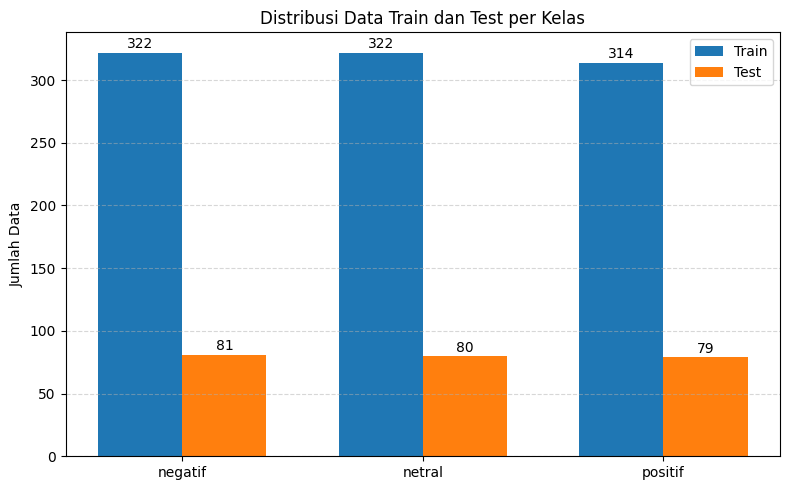

In [ ]:
# nama kelas dari LabelEncoder
classes = list(le.classes_)

# hitung jumlah tiap kelas
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

# pastikan semua kelas muncul
train_counts = train_counts.reindex(range(len(classes)), fill_value=0)
test_counts  = test_counts.reindex(range(len(classes)), fill_value=0)

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(
    x - width/2,
    train_counts.values,
    width,
    label='Train'
)

bars2 = plt.bar(
    x + width/2,
    test_counts.values,
    width,
    label='Test'
)

plt.xticks(x, classes)
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data Train dan Test per Kelas')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)

# tampilkan angka di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{int(bar.get_height())}',
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

#Train Data

Persiapan Korpus

In [ ]:
corpus = X_train_text

# Gabungkan kembali token menjadi string (IndoBERT butuh raw text)
corpus_text = [
    ' '.join(tokens) if isinstance(tokens, list) else tokens
    for tokens in corpus
]

print(f"Jumlah dokumen : {len(corpus_text)}")

Jumlah dokumen : 958


Load IndoBERT

###### 1: RAM & timer load ⏲



###Load Model

In [ ]:
# ============================================================
# TIMER + RAM LOAD MODEL
# ============================================================

ram_before = get_ram_usage()

start_load = time.perf_counter()

# ============================================================
# LOAD MODEL
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

indobert_model = AutoModel.from_pretrained(
    MODEL_NAME
)

indobert_model.eval()

# ============================================================
# TIMER SELESAI
# ============================================================

end_load = time.perf_counter()

ram_after = get_ram_usage()

waktu_load = (
    end_load - start_load
)

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nWaktu Load Model : "
    f"{waktu_load:.2f} detik"
)

print(
    f"RAM Sebelum      : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah      : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM     : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="IndoBERT",

    tahap="Load Model",

    parameter="indobert-base-p1",

    waktu=waktu_load,

    ram_before=ram_before,

    ram_after=ram_after
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Waktu Load Model : 1.46 detik
RAM Sebelum      : 7.12 GB
RAM Sesudah      : 7.33 GB
Kenaikan RAM     : 0.20 GB


Gunakan GPU jika tersedia

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
indobert_model = indobert_model.to(device)

print(f"\nModel     : {MODEL_NAME}")
print(f"Device    : {device}")


Model     : indobenchmark/indobert-base-p1
Device    : cpu


## IndoBERT Train

###kombinasi parameter

In [ ]:
param_grid = {
    "layer_strategy": ["last", "last4"]
}

In [ ]:
all_combinations = list(
    itertools.product(
        param_grid["layer_strategy"]
    )
)

print(f"Total kombinasi: {len(all_combinations)}")

Total kombinasi: 2


### 2: RAM & timer embedding ⏲

###Ektraksi Fitur

In [ ]:
import numpy as np
import torch

def teks_ke_vektor_indobert_token(
    texts,
    model,
    tokenizer,
    device,
    batch_size=32,
    max_length=32,
    layer_strategy='last'
):

    all_vectors = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        encoded = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            k: v.to(device)
            for k, v in encoded.items()
        }

        with torch.no_grad():

            output = model(
                **encoded,
                output_hidden_states=True
            )

        # =========================================
        # LAST LAYER
        # =========================================

        if layer_strategy == 'last':

            hidden_states = output.last_hidden_state

        # =========================================
        # LAST 4 LAYER
        # =========================================

        elif layer_strategy == 'last4':

            hidden_states = torch.stack(
                output.hidden_states[-4:]
            ).mean(dim=0)

        else:

            raise ValueError(
                "layer_strategy harus "
                "'last' atau 'last4'"
            )

        vectors = hidden_states.cpu().numpy()

        all_vectors.append(vectors)

    return np.vstack(all_vectors)


In [ ]:
import itertools

# ============================================================
# PARAMETER GRID
# ============================================================

param_grid = {

    "max_length": [32],

    "layer_strategy": [
        "last",
        "last4"
    ]
}

# ============================================================
# KOMBINASI
# ============================================================

all_combinations = list(

    itertools.product(

        param_grid["max_length"],

        param_grid["layer_strategy"]
    )
)

print(
    "Jumlah kombinasi :",
    len(all_combinations)
)

# ============================================================
# TEMPAT PENYIMPANAN
# ============================================================

all_embeddings = {}

# ============================================================
# LOOP EMBEDDING
# ============================================================

for (
    max_length,
    layer_strategy
) in all_combinations:

    # ========================================================
    # NAMA EMBEDDING
    # ========================================================

    key = (
        f"ml{max_length}_"
        f"{layer_strategy}"
    )

    print("\n====================================")

    print(f"Embedding : {key}")

    print("====================================")

    # ========================================================
    # RAM SEBELUM
    # ========================================================

    ram_before = get_ram_usage()

    # ========================================================
    # TIMER MULAI
    # ========================================================

    start_embed = time.perf_counter()

    # ========================================================
    # EMBEDDING
    # ========================================================

    X_embed = teks_ke_vektor_indobert_token(

        texts=corpus_text,

        model=indobert_model,

        tokenizer=tokenizer,

        device=device,

        batch_size=32,

        max_length=max_length,

        layer_strategy=layer_strategy
    )

    # ========================================================
    # TIMER SELESAI
    # ========================================================

    end_embed = time.perf_counter()

    waktu_embed = (
        end_embed - start_embed
    )

    # ========================================================
    # RAM SESUDAH
    # ========================================================

    ram_after = get_ram_usage()

    ram_used = (
        ram_after - ram_before
    )

    # ========================================================
    # PRINT MONITORING
    # ========================================================

    print(
        f"Waktu Embedding : "
        f"{waktu_embed:.2f} detik"
    )

    print(
        f"RAM Sebelum     : "
        f"{ram_before:.2f} GB"
    )

    print(
        f"RAM Sesudah     : "
        f"{ram_after:.2f} GB"
    )

    print(
        f"Kenaikan RAM    : "
        f"{ram_used:.2f} GB"
    )

    # ========================================================
    # SIMPAN MONITORING
    # ========================================================

    simpan_monitoring(

        metode="IndoBERT",

        tahap="Embedding",

        parameter=(
            f"max_length={max_length}, "
            f"layer={layer_strategy}, "
            f"batch=32"
        ),

        waktu=waktu_embed,

        ram_before=ram_before,

        ram_after=ram_after
    )

    # ========================================================
    # UNTUK BiLSTM
    # ========================================================

    X_bilstm = X_embed

    # ========================================================
    # SIMPAN EMBEDDING
    # ========================================================

    all_embeddings[key] = {

        "X_embed": X_embed,

        "X_bilstm": X_bilstm,

        "waktu_embedding": waktu_embed,

        "ram_before": ram_before,

        "ram_after": ram_after,

        "ram_used": ram_used,

        "params": {

            "max_length": max_length,

            "layer_strategy": layer_strategy,

            "batch_size": 32
        }
    }

    # ========================================================
    # SHAPE
    # ========================================================

    print(
        f"Shape embedding : "
        f"{X_embed.shape}"
    )

    print(
        f"Shape BiLSTM    : "
        f"{X_bilstm.shape}"
    )

Jumlah kombinasi : 2

Embedding : ml32_last
Waktu Embedding : 81.93 detik
RAM Sebelum     : 7.24 GB
RAM Sesudah     : 8.80 GB
Kenaikan RAM    : 1.57 GB
Shape embedding : (958, 32, 768)
Shape BiLSTM    : (958, 32, 768)

Embedding : ml32_last4
Waktu Embedding : 66.37 detik
RAM Sebelum     : 8.80 GB
RAM Sesudah     : 9.04 GB
Kenaikan RAM    : 0.23 GB
Shape embedding : (958, 32, 768)
Shape BiLSTM    : (958, 32, 768)


##BiLSTM Train

####kombinasi parameter

In [ ]:
epochs_list = [10, 20]
batch_size_list = [16, 32, 64]

###cross validation

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

###Persiapan Data Train

In [ ]:
results = []

for key, data in all_embeddings.items():

    print(f"\nModel : {key}")

    X = np.array(data["X_bilstm"])
    y = np.array(y_train)

    if len(X) != len(y):
        continue

    print("Shape X :", X.shape)
    print("Shape y :", y.shape)


Model : ml32_last
Shape X : (958, 32, 768)
Shape y : (958,)

Model : ml32_last4
Shape X : (958, 32, 768)
Shape y : (958,)


###Arsitektur BiLSTM

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
def build_bilstm_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(
            LSTM(64,
                dropout=0.5,
                recurrent_dropout=0.5,
                kernel_regularizer=l2(1e-4)) ),
        Dense(64,
            activation='relu',
            kernel_regularizer=l2(1e-4)),

        Dropout(0.5),
        Dense(3, activation='softmax')])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy'])

    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5)

### 3: RAM & timer tuning ⏲

###Tunning Hiperparameter

In [ ]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

In [ ]:
import torch

results = []

all_fold_scores = []

# ============================================================
# LOOP EMBEDDING
# ============================================================

for key, data in all_embeddings.items():

    print(f"\n===== {key} =====")

    X = np.array(data["X_bilstm"])
    y = np.array(y_train)

    if len(X) != len(y):
        continue

    # ========================================================
    # LOOP EPOCH
    # ========================================================

    for epochs in epochs_list:

        # ====================================================
        # LOOP BATCH SIZE
        # ====================================================

        for batch_size in batch_size_list:

            # =================================================
            # RAM SEBELUM TRAINING
            # =================================================

            ram_before = get_ram_usage()

            # =================================================
            # TIMER MULAI
            # =================================================

            start_train = time.perf_counter()

            accs = []

            # =================================================
            # CROSS VALIDATION
            # =================================================

            for fold, (train_idx, val_idx) in enumerate(

                skf.split(X, y),
                start=1
            ):

                tf.keras.backend.clear_session()

                X_train_fold = X[train_idx]
                X_val_fold   = X[val_idx]

                y_train_fold = y[train_idx]
                y_val_fold   = y[val_idx]

                # =============================================
                # BUILD MODEL
                # =============================================

                model = build_bilstm_model(

                    input_shape=(
                        X.shape[1],
                        X.shape[2]
                    )
                )

                # =============================================
                # TRAINING
                # =============================================

                model.fit(

                    X_train_fold,

                    y_train_fold,

                    validation_data=(
                        X_val_fold,
                        y_val_fold
                    ),

                    epochs=epochs,

                    batch_size=batch_size,

                    callbacks=[
                        early_stop,
                        reduce_lr
                    ],

                    verbose=0
                )

                # =============================================
                # EVALUASI
                # =============================================

                _, acc = model.evaluate(

                    X_val_fold,
                    y_val_fold,
                    verbose=0
                )

                accs.append(acc)

            # =================================================
            # TIMER SELESAI
            # =================================================

            end_train = time.perf_counter()

            waktu_train = (
                end_train - start_train
            )

            # =================================================
            # RAM SESUDAH TRAINING
            # =================================================

            ram_after = get_ram_usage()

            ram_used = (
                ram_after - ram_before
            )

            # =================================================
            # METRIK
            # =================================================

            mean_acc = np.mean(accs)

            std_acc = np.std(accs)

            # =================================================
            # PRINT HASIL
            # =================================================

            print(
                f"\nep={epochs} | "
                f"bs={batch_size} | "
                f"acc={mean_acc:.4f} ± {std_acc:.4f} | "
                f"waktu={waktu_train:.2f} detik | "
                f"RAM={ram_after:.2f} GB"
            )

            print(
                f"Kenaikan RAM : "
                f"{ram_used:.2f} GB"
            )

            for i, fold_acc in enumerate(
                accs,
                start=1
            ):

                print(
                    f"Fold {i} Accuracy : "
                    f"{fold_acc:.4f}"
                )

            # =================================================
            # SIMPAN MONITORING
            # =================================================

            simpan_monitoring(

                metode="IndoBERT-BiLSTM",

                tahap="Training CV",

                parameter=(
                    f"{key}, "
                    f"ep={epochs}, "
                    f"bs={batch_size}"
                ),

                waktu=waktu_train,

                ram_before=ram_before,

                ram_after=ram_after
            )

            # =================================================
            # SIMPAN HASIL
            # =================================================

            result_dict = {

                "model": key,

                "epochs": epochs,

                "batch_size": batch_size,

                "mean_accuracy": mean_acc,

                "std": std_acc,

                "waktu_training": waktu_train,

                "ram_before": ram_before,

                "ram_after": ram_after,

                "ram_used": ram_used
            }

            for i, fold_acc in enumerate(
                accs,
                start=1
            ):

                result_dict[f"fold_{i}"] = fold_acc

            results.append(result_dict)

            all_fold_scores.append(result_dict)


===== ml32_last =====

ep=10 | bs=16 | acc=0.7683 ± 0.0495 | waktu=142.65 detik | RAM=7.88 GB
Kenaikan RAM : -0.98 GB
Fold 1 Accuracy : 0.8594
Fold 2 Accuracy : 0.7448
Fold 3 Accuracy : 0.7135
Fold 4 Accuracy : 0.7749
Fold 5 Accuracy : 0.7487

ep=10 | bs=32 | acc=0.7046 ± 0.0124 | waktu=79.12 detik | RAM=8.21 GB
Kenaikan RAM : 0.33 GB
Fold 1 Accuracy : 0.6979
Fold 2 Accuracy : 0.6979
Fold 3 Accuracy : 0.6927
Fold 4 Accuracy : 0.7068
Fold 5 Accuracy : 0.7277

ep=10 | bs=64 | acc=0.7108 ± 0.0298 | waktu=78.74 detik | RAM=8.52 GB
Kenaikan RAM : 0.30 GB
Fold 1 Accuracy : 0.7135
Fold 2 Accuracy : 0.7656
Fold 3 Accuracy : 0.6771
Fold 4 Accuracy : 0.7016
Fold 5 Accuracy : 0.6963

ep=20 | bs=16 | acc=0.7307 ± 0.0253 | waktu=110.66 detik | RAM=8.79 GB
Kenaikan RAM : 0.27 GB
Fold 1 Accuracy : 0.7240
Fold 2 Accuracy : 0.7552
Fold 3 Accuracy : 0.6979
Fold 4 Accuracy : 0.7644
Fold 5 Accuracy : 0.7120

ep=20 | bs=32 | acc=0.7098 ± 0.0415 | waktu=83.22 detik | RAM=9.17 GB
Kenaikan RAM : 0.38 GB
Fold

###Model Indobert Terbaik

In [ ]:

# ============================================================
# DATAFRAME HASIL
# ============================================================

results_df = pd.DataFrame(results)

# ============================================================
# SORT BERDASARKAN ACCURACY
# ============================================================

results_df = results_df.sort_values(
    by="mean_accuracy",
    ascending=False
)

print("\n===== TOP HASIL TUNING =====")

display(results_df.head())

# ============================================================
# MODEL TERBAIK
# ============================================================

best_result = results_df.iloc[0]

print("\n===== BEST PARAMETER =====")

print(best_result)

best_model_key = best_result["model"]

best_epochs = int(
    best_result["epochs"]
)

best_batch_size = int(
    best_result["batch_size"]
)

best_acc = best_result["mean_accuracy"]

best_std = best_result["std"]

# ============================================================
# PARAMETER TERBAIK
# ============================================================

print("\n===== PARAMETER TERBAIK =====")

print("Model :", best_model_key)

print("Epochs :", best_epochs)

print("Batch Size :", best_batch_size)

print(
    f"Accuracy : "
    f"{best_acc:.4f} ± {best_std:.4f}"
)

# ============================================================
# PARAMETER EMBEDDING TERBAIK
# ============================================================

best_params = all_embeddings[
    best_model_key
]["params"]

print("\n===== PARAMETER EMBEDDING =====")

print(
    "max_length :",
    best_params["max_length"]
)

print(
    "layer_strategy :",
    best_params["layer_strategy"]
)



===== TOP HASIL TUNING =====


,model,epochs,batch_size,mean_accuracy,std,waktu_training,ram_before,ram_after,ram_used,fold_1,fold_2,fold_3,fold_4,fold_5
6,ml32_last4,10,16,0.771395,0.018522,108.150208,9.6264,9.7760,0.1496,0.781250,0.791667,0.744792,0.785340,0.753927
0,ml32_last,10,16,0.768254,0.049545,142.651868,8.8641,7.8835,-0.9806,0.859375,0.744792,0.713542,0.774869,0.748691
9,ml32_last4,20,16,0.742234,0.039564,105.735056,10.4153,10.6959,0.2806,0.687500,0.713542,0.765625,0.801047,0.743455
3,ml32_last,20,16,0.730705,0.025316,110.655021,8.5166,8.7861,0.2695,0.723958,0.755208,0.697917,0.764398,0.712042
7,ml32_last4,10,32,0.716099,0.034915,86.057408,9.7760,10.0821,0.3061,0.661458,0.765625,0.697917,0.722513,0.732984



===== BEST PARAMETER =====
model             ml32_last4
epochs                    10
batch_size                16
mean_accuracy       0.771395
std                 0.018522
waktu_training    108.150208
ram_before            9.6264
ram_after              9.776
ram_used              0.1496
fold_1               0.78125
fold_2              0.791667
fold_3              0.744792
fold_4               0.78534
fold_5              0.753927
Name: 6, dtype: object

===== PARAMETER TERBAIK =====
Model : ml32_last4
Epochs : 10
Batch Size : 16
Accuracy : 0.7714 ± 0.0185

===== PARAMETER EMBEDDING =====
max_length : 32
layer_strategy : last4


In [ ]:
X_train_best = all_embeddings[
    best_model_key
]["X_bilstm"]

y_train_final = np.array(y_train)

print("Shape X :", X_train_best.shape)

print("Shape y :", y_train_final.shape)


Shape X : (958, 32, 768)
Shape y : (958,)


##Bangun Model

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# ============================================================
# BUILD FINAL MODEL
# ============================================================

final_model = build_bilstm_model(

    input_shape=(

        X_train_best.shape[1],

        X_train_best.shape[2]
    )
)

# ============================================================
# RINGKASAN MODEL
# ============================================================

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       426,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,947 (1.66 MB)

 Trainable params: 434,947 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

### 4: RAM & timer final train ⏲

In [ ]:
# ============================================================
# RAM SEBELUM FINAL TRAINING
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_final = time.perf_counter()

# ============================================================
# FINAL TRAINING
# ============================================================

history = final_model.fit(

    X_train_best,

    y_train_final,

    epochs=best_epochs,

    batch_size=best_batch_size,

    validation_split=0.2,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_final = time.perf_counter()

waktu_final = (
    end_final - start_final
)

# ============================================================
# RAM SESUDAH TRAINING
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nFinal Training Time : "
    f"{waktu_final:.2f} detik"
)

print(
    f"RAM Sebelum         : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah         : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM        : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="IndoBERT-BiLSTM",

    tahap="Final Training",

    parameter=(
        f"{best_model_key}, "
        f"ep={best_epochs}, "
        f"bs={best_batch_size}"
    ),

    waktu=waktu_final,

    ram_before=ram_before,

    ram_after=ram_after
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.5000 - loss: 1.0938 - val_accuracy: 0.7240 - val_loss: 0.8078 - learning_rate: 0.0010
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7023 - loss: 0.7937 - val_accuracy: 0.7604 - val_loss: 0.6651 - learning_rate: 0.0010
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.7937 - loss: 0.6431 - val_accuracy: 0.7500 - val_loss: 0.6319 - learning_rate: 5.0000e-04

Final Training Time : 17.15 detik
RAM Sebelum         : 11.00 GB
RAM Sesudah         : 10.98 GB
Kenaikan RAM        : -0.02 GB


#Test

## 5: RAM & timer embed test ⏲

##Embedding Data Test

In [ ]:
# ============================================================
# RAM SEBELUM TEST EMBEDDING
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_test_embed = time.perf_counter()

# ============================================================
# DATA TEST EMBEDDING
# ============================================================

X_test_embed = teks_ke_vektor_indobert_token(

    texts=X_test_text,

    model=indobert_model,

    tokenizer=tokenizer,

    device=device,

    batch_size=32,

    max_length=best_params["max_length"],

    layer_strategy=best_params["layer_strategy"]
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_test_embed = time.perf_counter()

waktu_test_embed = (
    end_test_embed - start_test_embed
)

# ============================================================
# RAM SESUDAH EMBEDDING
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nTest Embedding Time : "
    f"{waktu_test_embed:.2f} detik"
)

print(
    f"RAM Sebelum         : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah         : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM        : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="IndoBERT",

    tahap="Test Embedding",

    parameter=(
        f"max_length={best_params['max_length']}, "
        f"layer={best_params['layer_strategy']}, "
        f"batch=8"
    ),

    waktu=waktu_test_embed,

    ram_before=ram_before,

    ram_after=ram_after
)


Test Embedding Time : 16.00 detik
RAM Sebelum         : 10.98 GB
RAM Sesudah         : 11.07 GB
Kenaikan RAM        : 0.10 GB


In [ ]:
X_test_final = X_test_embed

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

##6: RAM & timer Prediksi ⏲

##Prediksi Data Test

In [ ]:
# ============================================================
# RAM SEBELUM PREDIKSI
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_pred = time.perf_counter()

# ============================================================
# PREDIKSI TEST
# ============================================================

y_pred_prob = final_model.predict(
    X_test_final
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_pred = time.perf_counter()

waktu_pred = (
    end_pred - start_pred
)

# ============================================================
# RAM SESUDAH PREDIKSI
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nPrediction Time : "
    f"{waktu_pred:.2f} detik"
)

print(
    f"RAM Sebelum     : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah     : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM    : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="IndoBERT-BiLSTM",

    tahap="Prediction",

    parameter=(
        f"test_size={len(X_test_final)}"
    ),

    waktu=waktu_pred,

    ram_before=ram_before,

    ram_after=ram_after
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

Prediction Time : 1.32 detik
RAM Sebelum     : 11.07 GB
RAM Sesudah     : 10.75 GB
Kenaikan RAM    : -0.32 GB


In [ ]:
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

test_acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"\nTest Accuracy : "
    f"{test_acc:.4f}")


Test Accuracy : 0.7417


In [ ]:
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    sensitivitas = []
    spesifisitas = []

    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        sensitivitas.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
        spesifisitas.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

    return {
        'Accuracy'          : accuracy_score(y_true, y_pred),
        'F1 Score'          : f1_score(y_true, y_pred, average='macro'),
        'Balanced Accuracy' : balanced_accuracy_score(y_true, y_pred),
        'Sensitivitas'      : np.mean(sensitivitas),
        'Spesifisitas'      : np.mean(spesifisitas)
    }

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# PREDIKSI TRAIN
# ============================================================

y_pred_train = np.argmax(
    final_model.predict(
        X_train_best,
        verbose=0
    ),
    axis=1
)

# ============================================================
# PREDIKSI TEST
# ============================================================

y_pred_test = np.argmax(
    final_model.predict(
        X_test_final,
        verbose=0
    ),
    axis=1
)

# ============================================================
# METRIK
# ============================================================

metrik_train = get_metrics(
    y_train,
    y_pred_train
)

metrik_test = get_metrics(
    y_test,
    y_pred_test
)

# ============================================================
# URUTAN METRIK
# ============================================================

labels = [
    'Accuracy',
    'F1 Score',
    'Balanced Accuracy',
    'Sensitivitas',
    'Spesifisitas'
]

train_values = [
    metrik_train[k]
    for k in labels
]

test_values = [
    metrik_test[k]
    for k in labels
]

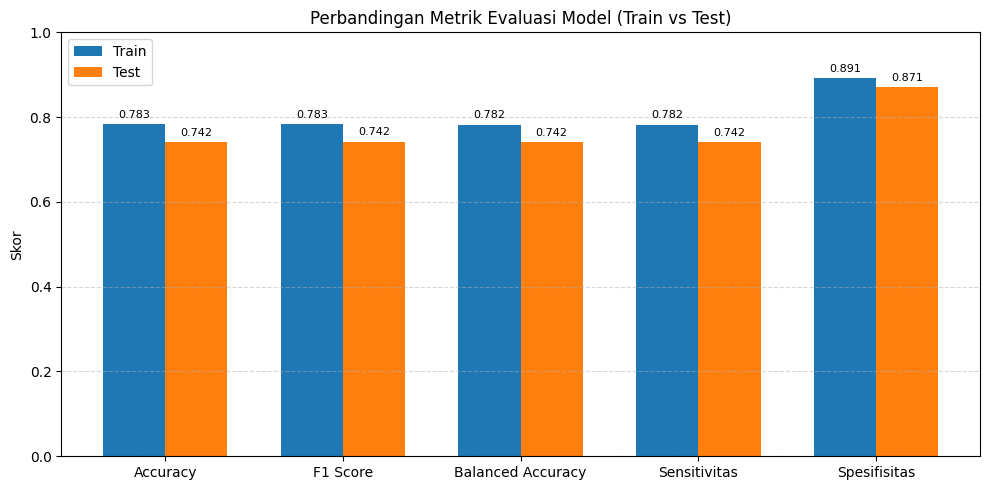

In [ ]:
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(
    x - width/2,
    train_values,
    width,
    label='Train'
)

bars2 = plt.bar(
    x + width/2,
    test_values,
    width,
    label='Test'
)

plt.xticks(x, labels)

plt.ylim(0, 1)

plt.title(
    'Perbandingan Metrik Evaluasi Model (Train vs Test)'
)

plt.ylabel('Skor')

plt.legend()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# ============================================================
# LABEL NILAI
# ============================================================

for bars in [bars1, bars2]:

    for bar in bars:

        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()

plt.show()

#Confusion Matrix

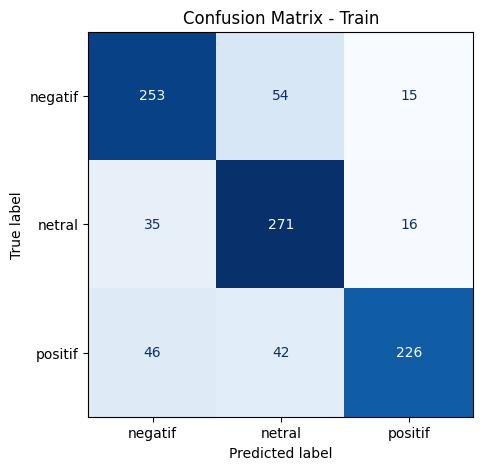

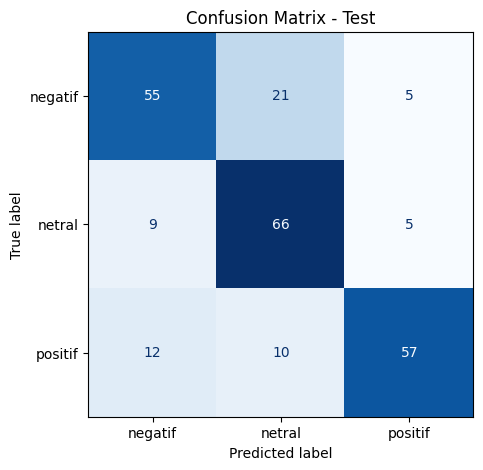

In [ ]:
cm_train = confusion_matrix(
    y_train,
    y_pred_train
)

disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_train.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Train")

plt.grid(False)

plt.show()

# ============================================================
# CONFUSION MATRIX TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_test.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Test")

plt.grid(False)

plt.show()

#Top Fitur

##Top Fitur Frequency

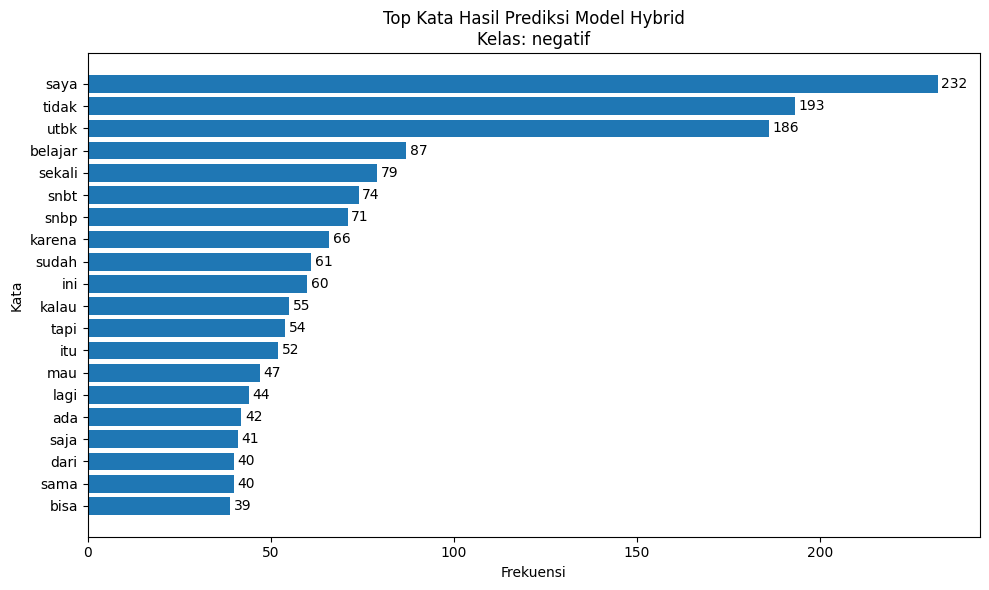

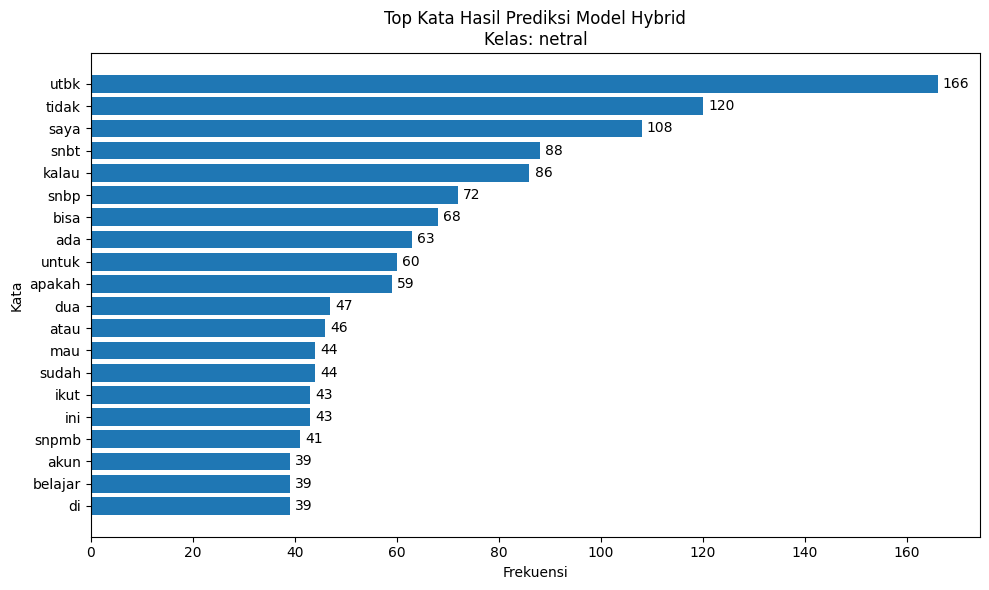

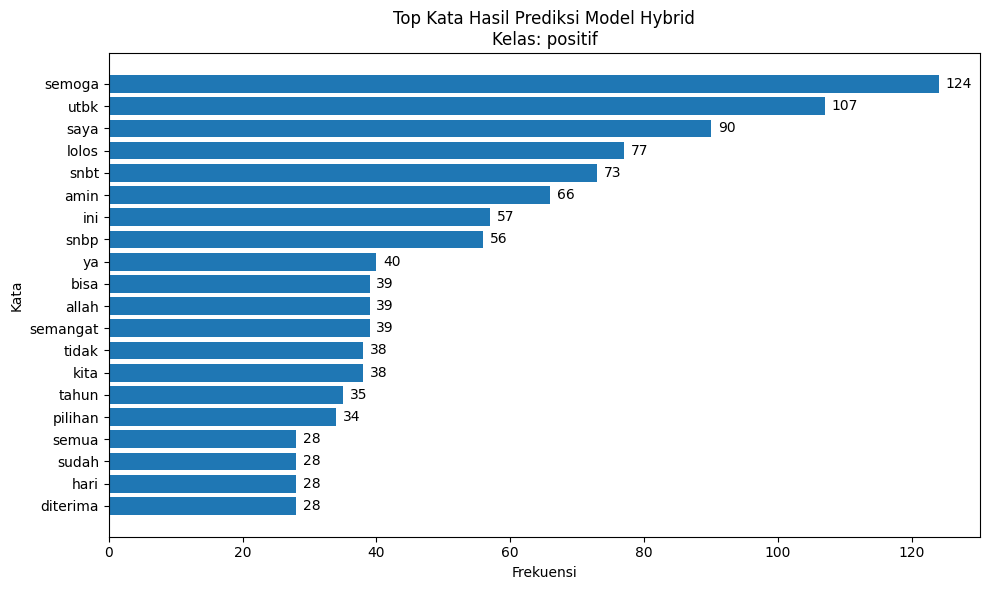

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# PREDIKSI MODEL HYBRID
# ============================================================

y_pred_train = np.argmax(

    final_model.predict(
        X_train_best,
        verbose=0
    ),

    axis=1
)

# ============================================================
# LABEL KELAS
# ============================================================

classes = list(le.classes_)

# ============================================================
# LOOP TIAP KELAS HASIL PREDIKSI
# ============================================================

for idx, kelas in enumerate(classes):

    # ========================================================
    # AMBIL TEKS BERDASARKAN PREDIKSI MODEL
    # ========================================================

    teks_kelas = [

        text

        for text, pred in zip(
            X_train_text,
            y_pred_train
        )

        if pred == idx
    ]

    # ========================================================
    # GABUNG KATA
    # ========================================================

    semua_kata = ' '.join(
        teks_kelas
    ).split()

    # ========================================================
    # HITUNG FREKUENSI
    # ========================================================

    counter = Counter(
        semua_kata
    )

    top_kata = counter.most_common(20)

    kata = [
        x[0]
        for x in top_kata
    ]

    frek = [
        x[1]
        for x in top_kata
    ]

    # ========================================================
    # VISUALISASI
    # ========================================================

    plt.figure(figsize=(10,6))

    bars = plt.barh(
        kata,
        frek
    )

    plt.xlabel("Frekuensi")

    plt.ylabel("Kata")

    plt.title(

        f"Top Kata "
        f"Hasil Prediksi Model Hybrid\n"
        f"Kelas: {kelas}"

    )

    plt.gca().invert_yaxis()

    # ========================================================
    # LABEL ANGKA
    # ========================================================

    for bar in bars:

        plt.text(

            bar.get_width() + 1,

            bar.get_y()
            + bar.get_height()/2,

            str(int(bar.get_width())),

            va='center'
        )

    plt.tight_layout()

    plt.show()

##Top Fitur Chi Square

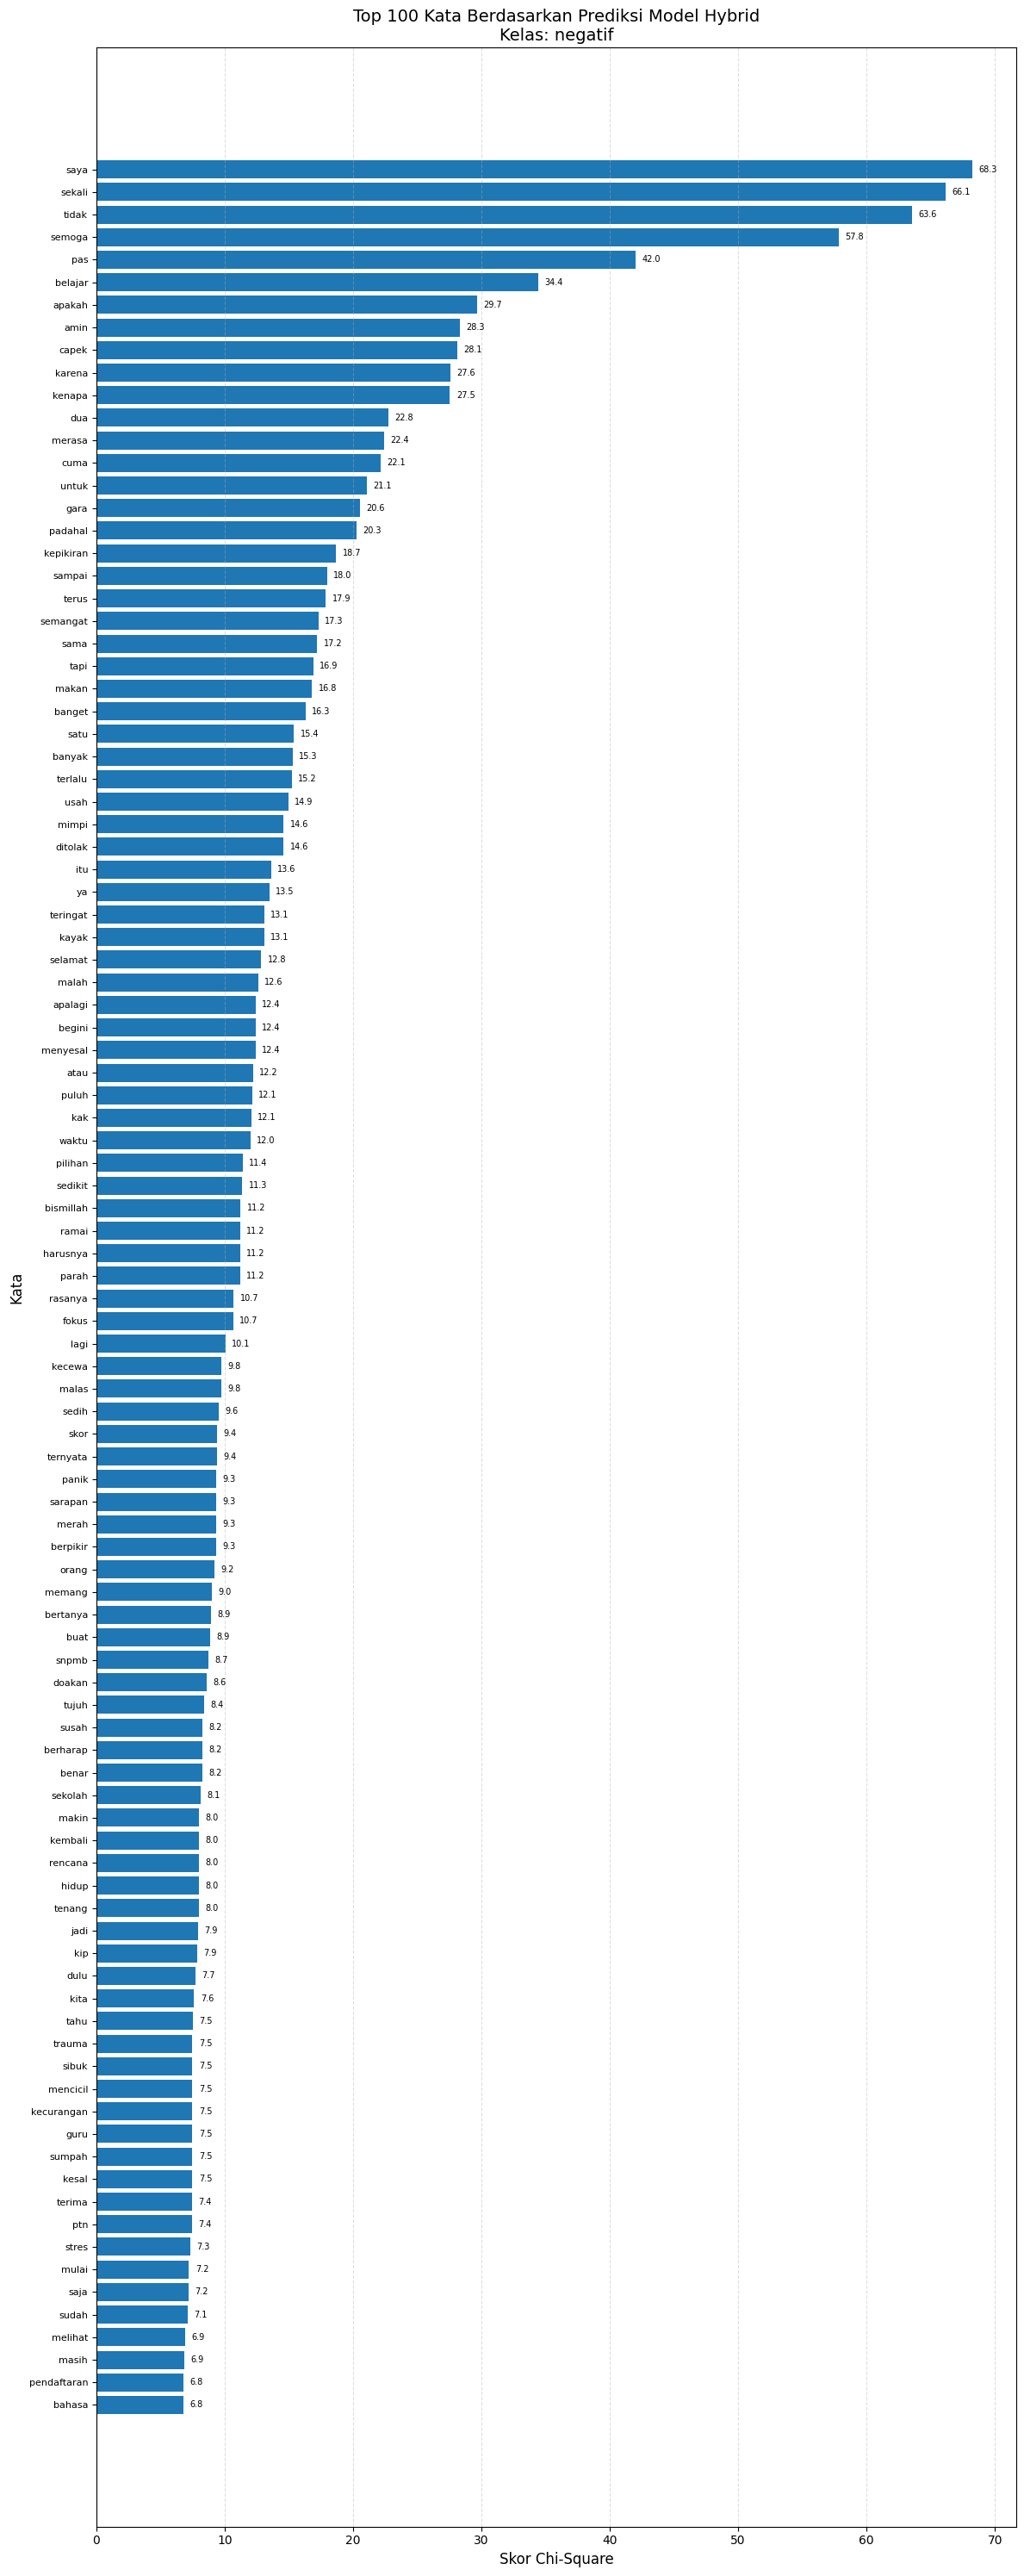

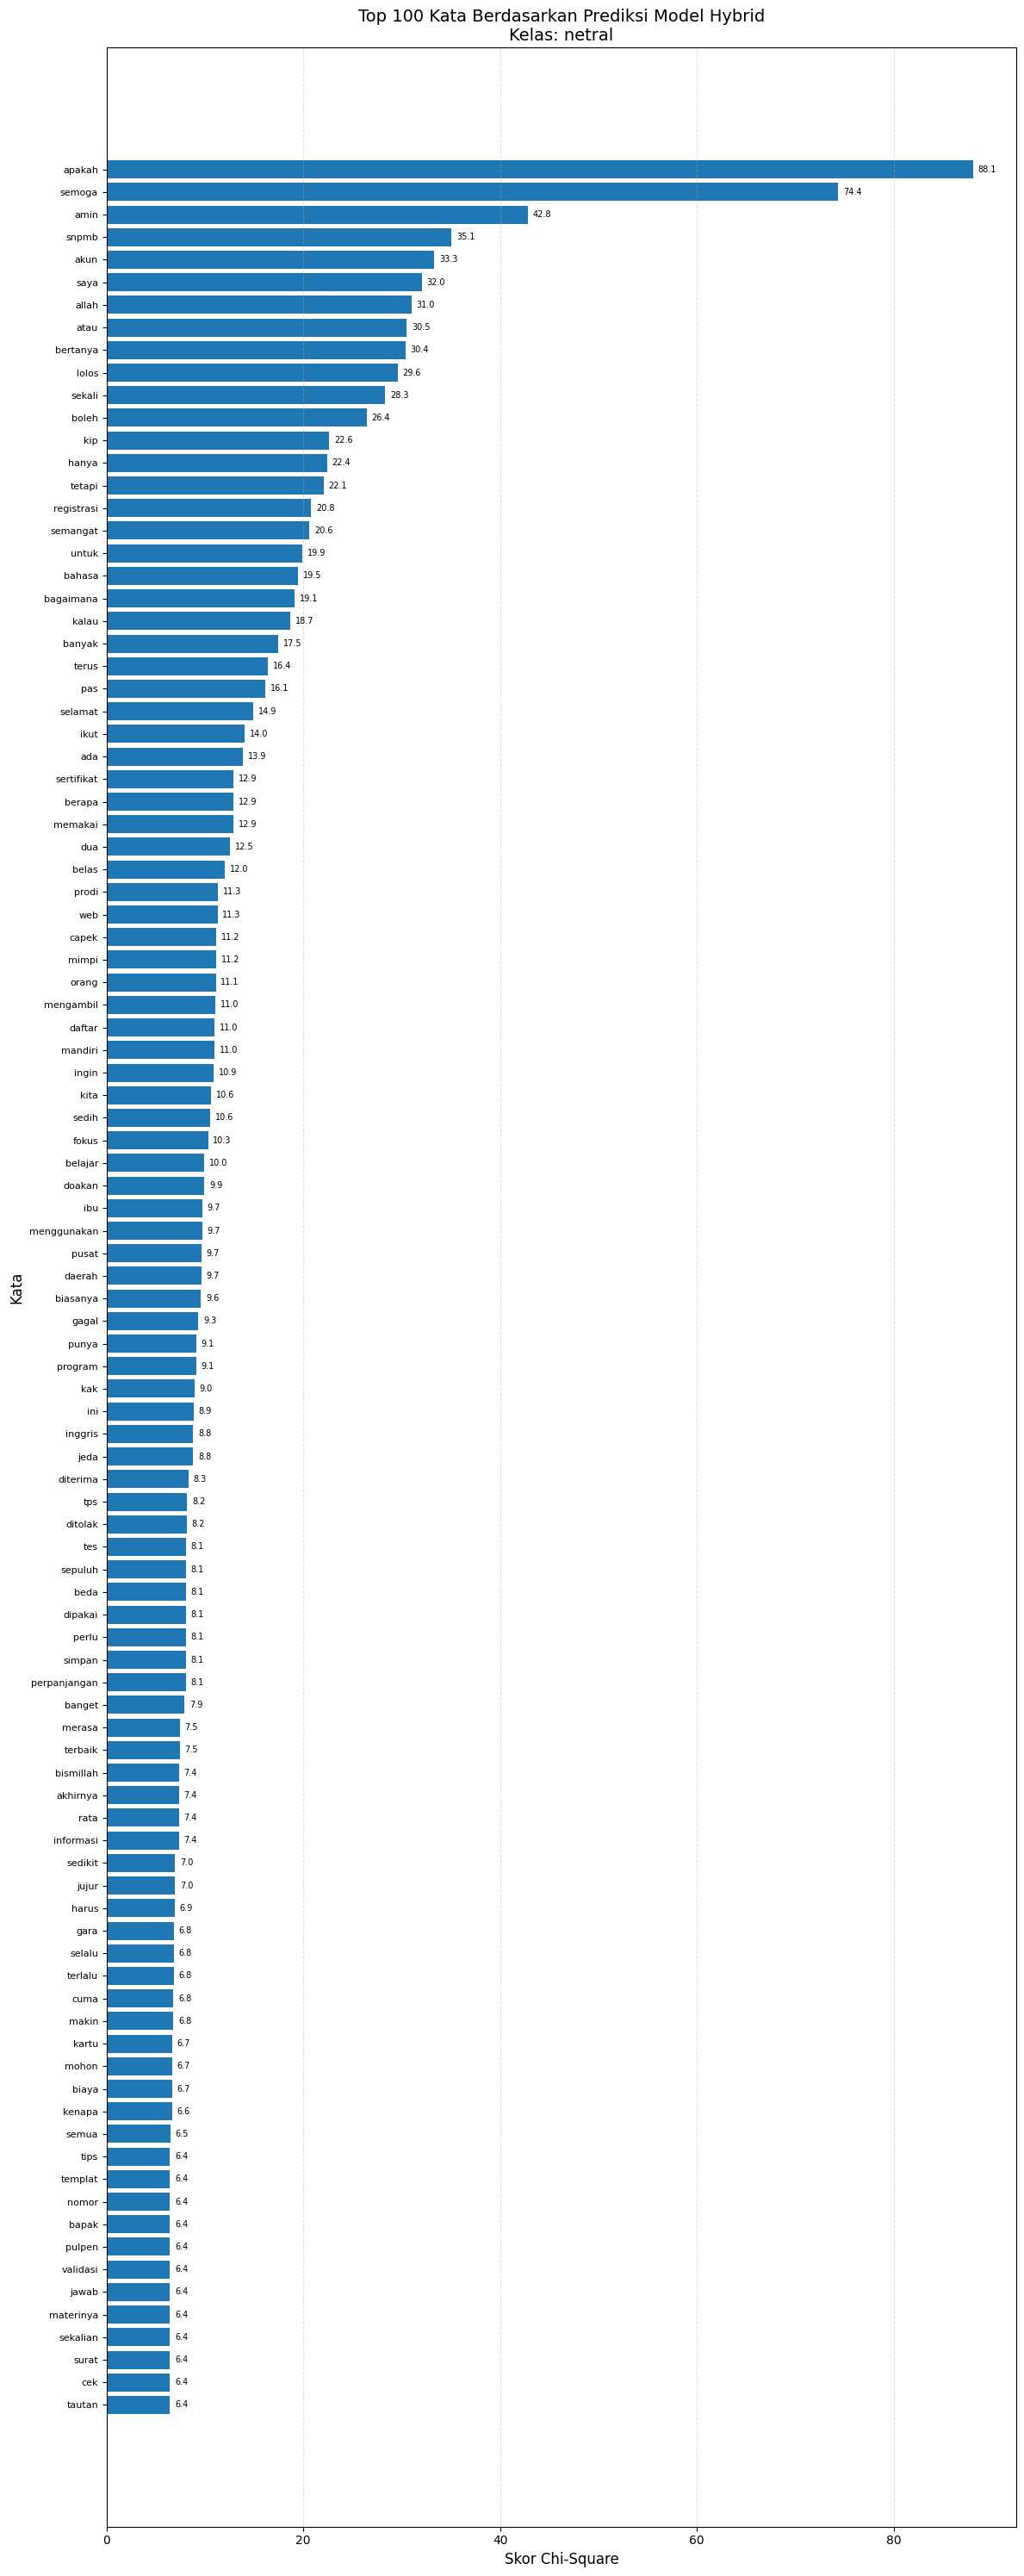

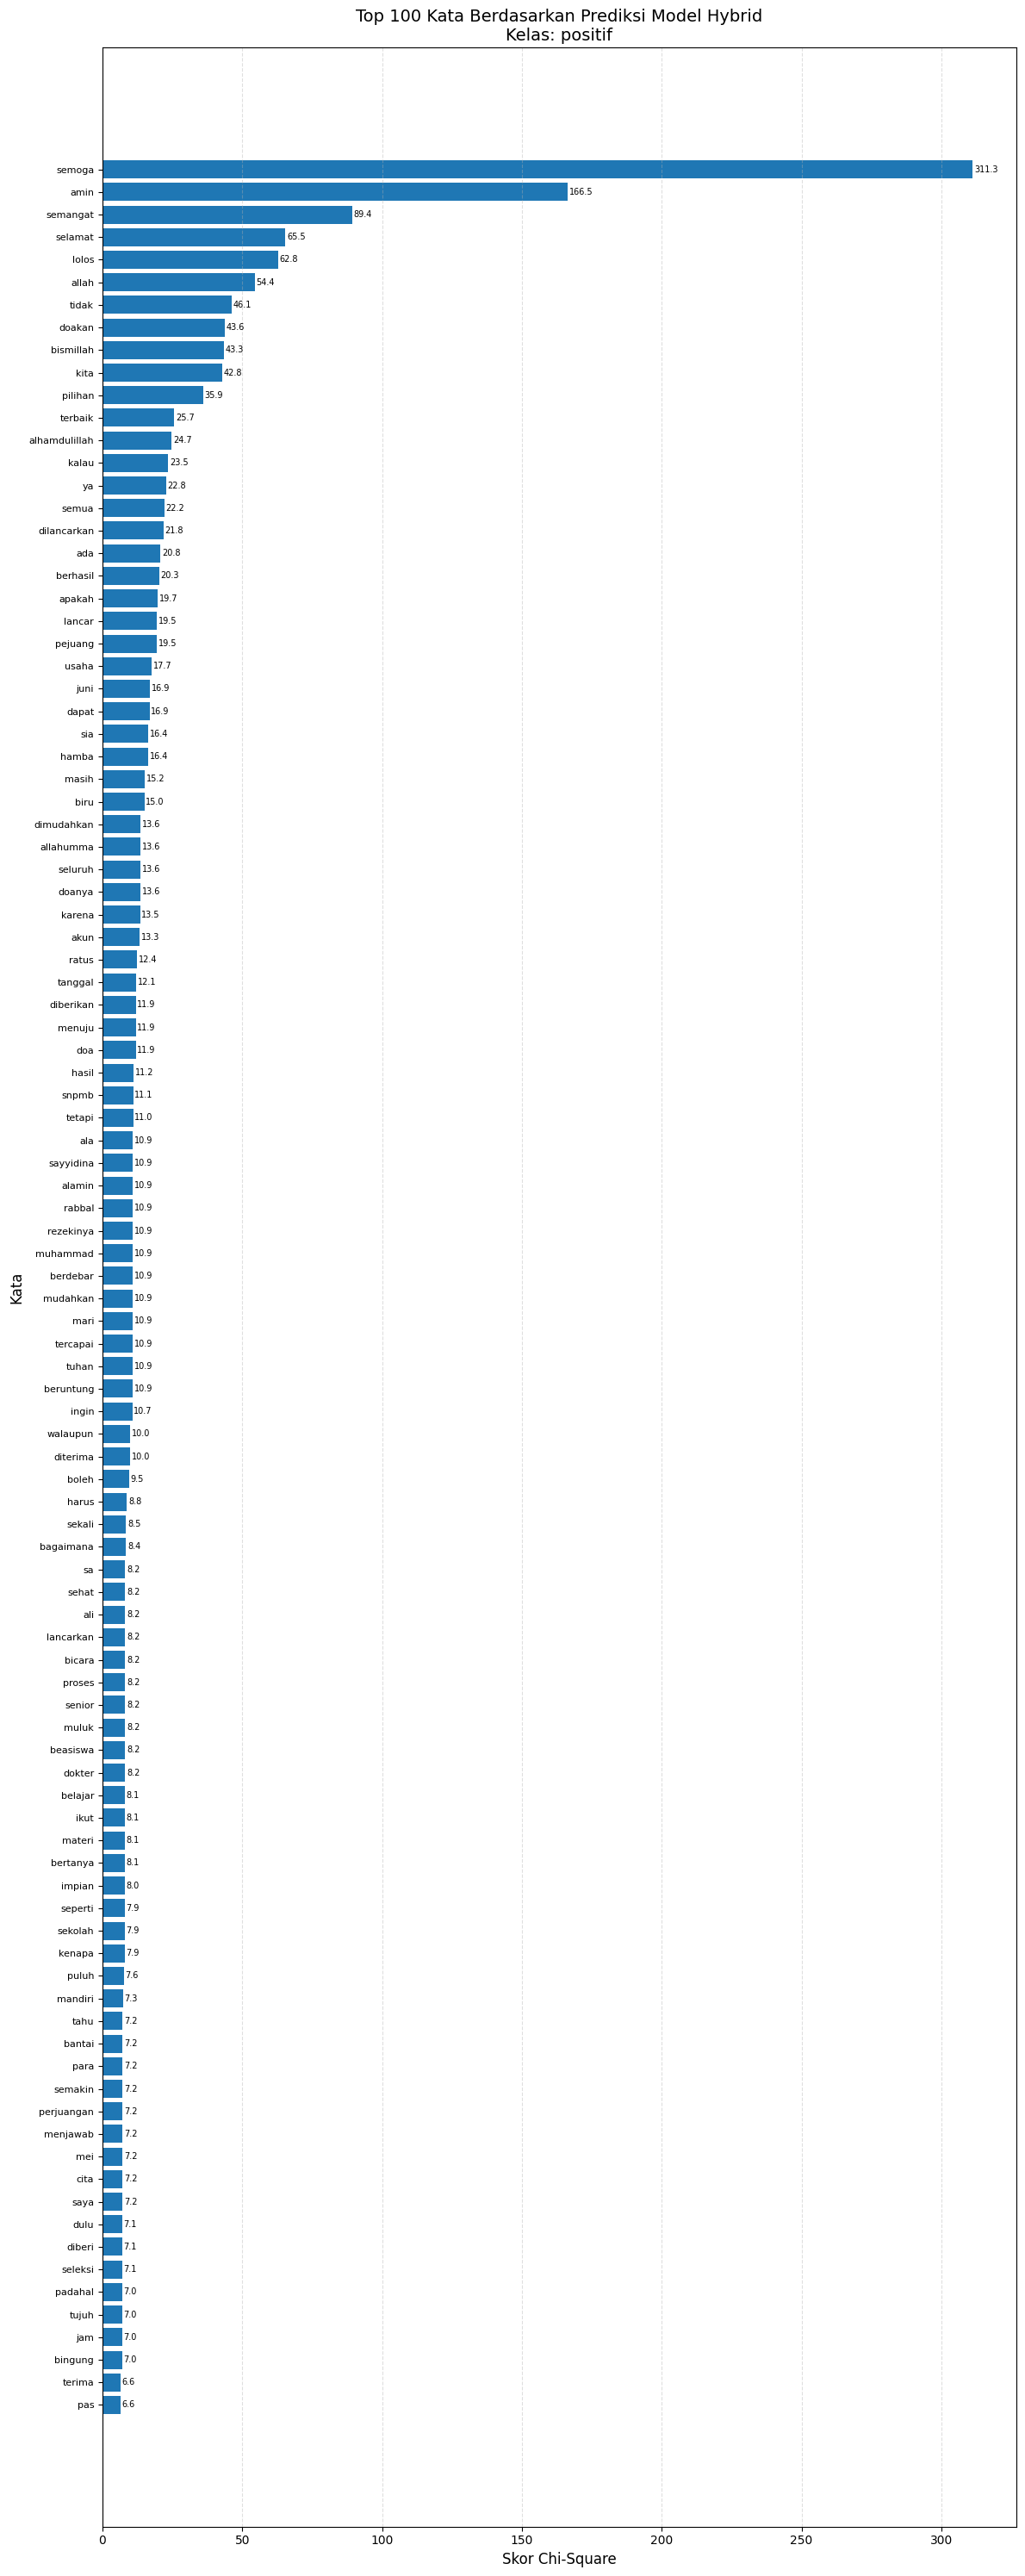

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PREDIKSI MODEL HYBRID
# ============================================================

y_pred_train = np.argmax(

    final_model.predict(
        X_train_best,
        verbose=0
    ),

    axis=1
)

# ============================================================
# COUNT VECTORIZER
# ============================================================

vectorizer = CountVectorizer(
    max_features=5000
)

X_count = vectorizer.fit_transform(
    X_train_text
)

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

# ============================================================
# LABEL KELAS
# ============================================================

classes = list(le.classes_)

# ============================================================
# LOOP PER KELAS PREDIKSI MODEL
# ============================================================

for idx, kelas in enumerate(classes):

    # ========================================================
    # LABEL BERDASARKAN PREDIKSI MODEL HYBRID
    # ========================================================

    y_binary = (
        y_pred_train == idx
    ).astype(int)

    # ========================================================
    # CHI-SQUARE
    # ========================================================

    chi_scores, _ = chi2(
        X_count,
        y_binary
    )

    # ========================================================
    # TOP KATA
    # ========================================================

    top_n = 100

    top_idx = chi_scores.argsort()[
        -top_n:
    ][::-1]

    top_kata = feature_names[
        top_idx
    ]

    top_skor = chi_scores[
        top_idx
    ]

    # ========================================================
    # VISUALISASI
    # ========================================================

    plt.figure(
        figsize=(12, 30)
    )

    bars = plt.barh(

        top_kata[::-1],

        top_skor[::-1]

    )

    # ========================================================
    # LABEL
    # ========================================================

    plt.xlabel(
        "Skor Chi-Square",
        fontsize=12
    )

    plt.ylabel(
        "Kata",
        fontsize=12
    )

    plt.title(

        f"Top {top_n} Kata "
        f"Berdasarkan Prediksi Model Hybrid\n"
        f"Kelas: {kelas}",

        fontsize=14
    )

    # ========================================================
    # FONT Y
    # ========================================================

    plt.yticks(
        fontsize=8
    )

    # ========================================================
    # NILAI DI BAR
    # ========================================================

    for bar in bars:

        plt.text(

            bar.get_width() + 0.5,

            bar.get_y()
            + bar.get_height()/2,

            f"{bar.get_width():.1f}",

            va='center',

            fontsize=7
        )

    # ========================================================
    # GRID
    # ========================================================

    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.4
    )

    # ========================================================
    # MARGIN
    # ========================================================

    plt.tight_layout()

    plt.show()

#Rekap RAM & TIMER

In [ ]:
# ============================================================
# REKAP MONITORING
# ============================================================

df_monitoring = pd.DataFrame(
    time_records
)

display(df_monitoring)

# ============================================================
# SIMPAN EXCEL
# ============================================================

output_path = (
    "/content/drive/MyDrive/Thesis/"
    "monitoring_indobert.xlsx"
)

df_monitoring.to_excel(

    output_path,

    index=False
)

print(
    f"\nMonitoring berhasil disimpan di:\n"
    f"{output_path}"
)

,Metode,Tahap,Parameter,Waktu (detik),RAM Sebelum (GB),RAM Sesudah (GB),Kenaikan RAM (GB)
0,IndoBERT,Load Model,indobert-base-p1,1.4553,7.1239,7.3250,0.2011
1,IndoBERT,Embedding,"max_length=32, layer=last, batch=32",81.9318,7.2375,8.8030,1.5655
2,IndoBERT,Embedding,"max_length=32, layer=last4, batch=32",66.3713,8.8030,9.0355,0.2325
3,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=10, bs=16",142.6519,8.8641,7.8835,-0.9806
4,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=10, bs=32",79.1221,7.8835,8.2117,0.3282
5,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=10, bs=64",78.7364,8.2117,8.5166,0.3049
6,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=20, bs=16",110.6550,8.5166,8.7861,0.2695
7,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=20, bs=32",83.2211,8.7861,9.1658,0.3797
8,IndoBERT-BiLSTM,Training CV,"ml32_last, ep=20, bs=64",77.6260,9.1658,9.5376,0.3718
9,IndoBERT-BiLSTM,Training CV,"ml32_last4, ep=10, bs=16",108.1502,9.6264,9.7760,0.1496



Monitoring berhasil disimpan di:
/content/drive/MyDrive/Thesis/monitoring_indobert.xlsx


In [ ]:
# ============================================================
# EXPORT ARTIFACTS - IndoBERT + BiLSTM
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

# ============================================================
# RE-DEFINE VARIABLES (self-contained)
# ============================================================

class_names = list(le.classes_)

# ============================================================
# LABEL ASLI & HASIL PREDIKSI
# ============================================================

# Train predictions
y_pred_train = np.argmax(
    final_model.predict(X_train_best, verbose=0),
    axis=1
)

# Test predictions
y_pred_test = np.argmax(
    final_model.predict(X_test_final, verbose=0),
    axis=1
)

# Decode label
label_asli_train = le.inverse_transform(y_train)
label_pred_train = le.inverse_transform(y_pred_train)

label_asli_test = le.inverse_transform(y_test)
label_pred_test = le.inverse_transform(y_pred_test)

# ============================================================
# SOFTMAX PROBABILITIES
# ============================================================

y_prob_train = final_model.predict(
    X_train_best,
    verbose=0
)

y_prob_test = final_model.predict(
    X_test_final,
    verbose=0
)

conf_train = np.max(y_prob_train, axis=1)
conf_test  = np.max(y_prob_test, axis=1)

# ============================================================
# DATAFRAME TRAIN
# ============================================================

df_train_result = pd.DataFrame({

    'teks'             : X_train_text,
    'data'             : 'train',
    'label_asli'       : label_asli_train,
    'label_prediksi'   : label_pred_train,
    'max_confidence'   : conf_train,
    'correct'          : (y_train == y_pred_train)

})

for idx, cls_name in enumerate(class_names):

    df_train_result[f'prob_{cls_name}'] = y_prob_train[:, idx]

# ============================================================
# DATAFRAME TEST
# ============================================================

df_test_result = pd.DataFrame({

    'teks'             : X_test_text,
    'data'             : 'test',
    'label_asli'       : label_asli_test,
    'label_prediksi'   : label_pred_test,
    'max_confidence'   : conf_test,
    'correct'          : (y_test == y_pred_test)

})

for idx, cls_name in enumerate(class_names):

    df_test_result[f'prob_{cls_name}'] = y_prob_test[:, idx]

# ============================================================
# GABUNG TRAIN + TEST
# ============================================================

df_hasil_klasifikasi = pd.concat(
    [df_train_result, df_test_result],
    ignore_index=True
)

display(df_hasil_klasifikasi.head())

# ============================================================
# SETUP OUTPUT DIRECTORY
# ============================================================

output_dir = (
    '/content/drive/MyDrive/Thesis/'
    'artifacts_indobert_bilstm'
)

os.makedirs(output_dir, exist_ok=True)

print(f"\nOutput directory : {output_dir}")
print(f"Classes          : {class_names}")

# ============================================================
# 1. SAVE PREDICTIONS + SOFTMAX
# ============================================================

predictions_path = os.path.join(
    output_dir,
    'predictions_with_softmax.xlsx'
)

df_hasil_klasifikasi.to_excel(
    predictions_path,
    index=False
)

print(f"\n✅ Predictions   : {predictions_path}")

# ============================================================
# 2. SAVE BILSTM MODEL
# ============================================================

model_path = os.path.join(
    output_dir,
    'bilstm_final_model.keras'
)

final_model.save(model_path)

print(f"✅ BiLSTM model  : {model_path}")

# ============================================================
# 3. SAVE LABEL ENCODER
# ============================================================

le_path = os.path.join(
    output_dir,
    'label_encoder.pkl'
)

joblib.dump(le, le_path)

print(f"✅ LabelEncoder  : {le_path}")

# ============================================================
# 4. SAVE CONFIG / METADATA
# ============================================================

metadata = {

    "model_type"          : "IndoBERT + BiLSTM",

    "indobert_model_name" : MODEL_NAME,

    "best_params" : {
        "max_length"     : int(best_params["max_length"]),
        "layer_strategy" : best_params["layer_strategy"],
        "epochs"         : int(best_epochs),
        "batch_size"     : int(best_batch_size)
    },

    "performance" : {
        "cv_mean_accuracy" : float(best_acc),
        "cv_std"           : float(best_std),
        "test_accuracy"    : float(test_acc)
    },

    "data_info" : {
        "num_train"   : len(X_train_text),
        "num_test"    : len(X_test_text),
        "num_classes" : len(class_names),
        "class_names" : class_names
    }
}

metadata_path = os.path.join(
    output_dir,
    'metadata.json'
)

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata      : {metadata_path}")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("EXPORT SUMMARY - IndoBERT + BiLSTM")
print("="*60)

for fname in sorted(os.listdir(output_dir)):

    fpath = os.path.join(output_dir, fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)

    print(f"  {fname:<35} {size_mb:>8.2f} MB")

print("="*60)
print(f"\n📂 Folder: {output_dir}")

,teks,data,label_asli,label_prediksi,max_confidence,correct,prob_negatif,prob_netral,prob_positif
0,agak menyesal ikut tka harusnya saya fokus snb...,train,negatif,negatif,0.420639,True,0.420639,0.350121,0.229240
1,lolos utbk tidak kak kalau iya universitas pr...,train,netral,netral,0.650222,True,0.174073,0.650222,0.175705
2,menuju lolos snbt,train,positif,positif,0.760529,True,0.111021,0.128449,0.760529
3,berita baik untuk kamu kawan pajak mau ikut s...,train,positif,netral,0.531682,False,0.184899,0.531682,0.283418
4,saya mau tanya lokasi ujian biasanya diumumkan...,train,netral,netral,0.774875,True,0.141030,0.774875,0.084096



Output directory : /content/drive/MyDrive/Thesis/artifacts_indobert_bilstm
Classes          : ['negatif', 'netral', 'positif']

✅ Predictions   : /content/drive/MyDrive/Thesis/artifacts_indobert_bilstm/predictions_with_softmax.xlsx
✅ BiLSTM model  : /content/drive/MyDrive/Thesis/artifacts_indobert_bilstm/bilstm_final_model.keras
✅ LabelEncoder  : /content/drive/MyDrive/Thesis/artifacts_indobert_bilstm/label_encoder.pkl
✅ Metadata      : /content/drive/MyDrive/Thesis/artifacts_indobert_bilstm/metadata.json

EXPORT SUMMARY - IndoBERT + BiLSTM
  bilstm_final_model.keras                5.02 MB
  bilstm_final_model_maxlen26_ep10_bs16_20260523_070809.keras     5.02 MB
  label_encoder.pkl                       0.00 MB
  label_encoder_maxlen26_ep10_bs16_20260523_070809.pkl     0.00 MB
  metadata.json                           0.00 MB
  metadata_maxlen26_ep10_bs16_20260523_070809.json     0.00 MB
  predictions_softmax_maxlen26_ep10_bs16_20260523_070809.xlsx     0.13 MB
  predictions_with_softm